# Patrón 13: CUA + HITL — Procesamiento de Reclamaciones de Seguro Médico



### ¿Qué es?

El patrón **CUA + HITL para acciones de alto riesgo** combina las capacidades del **Computer Use Agent** (percepción visual + control de UI) con la supervisión explícita del **Human-in-the-Loop** en cada punto del flujo donde una acción es **irreversible, costosa o de alto impacto**. El CUA actúa con autonomía en acciones seguras (navegar, leer, llenar formularios), pero se detiene y solicita aprobación humana antes de confirmar transacciones, eliminar datos, enviar comunicaciones o ejecutar cualquier operación que no se pueda deshacer.

Es la arquitectura de producción correcta para RPA inteligente en sistemas críticos: portales bancarios, sistemas de salud, CRMs, ERPs y cualquier entorno donde el error tiene costo real.


### ¿Por qué combinarlos?

| Sin HITL | Con HITL |
|---|---|
| CUA actúa completamente solo | CUA pausa en puntos críticos |
| Errores son irreversibles | Operador puede corregir antes de ejecutar |
| No hay trazabilidad de decisiones | Cada aprobación queda registrada en el checkpointer |
| Apto solo para ambientes de bajo riesgo | Apto para producción con sistemas críticos |



Dataset: leandrenash/enhanced-health-insurance-claims-dataset — 4,500 reclamaciones sintéticas con campos de diagnóstico, monto reclamado, tipo de tratamiento y estado de aprobación.

Caso de uso real: Un agente CUA navega el portal web de una aseguradora, lee el formulario de cada reclamación pendiente, clasifica su riesgo (monto alto, diagnóstico especial, fraude potencial) y pausa para que un operador apruebe, rechace o modifique antes de confirmar la acción en el portal.

Depedencias:
```bash
!pip install -q langgraph langchain langchain-anthropic \
               langchain-community pandas matplotlib seaborn \
               kaggle ipywidgets
```

Diagrama:

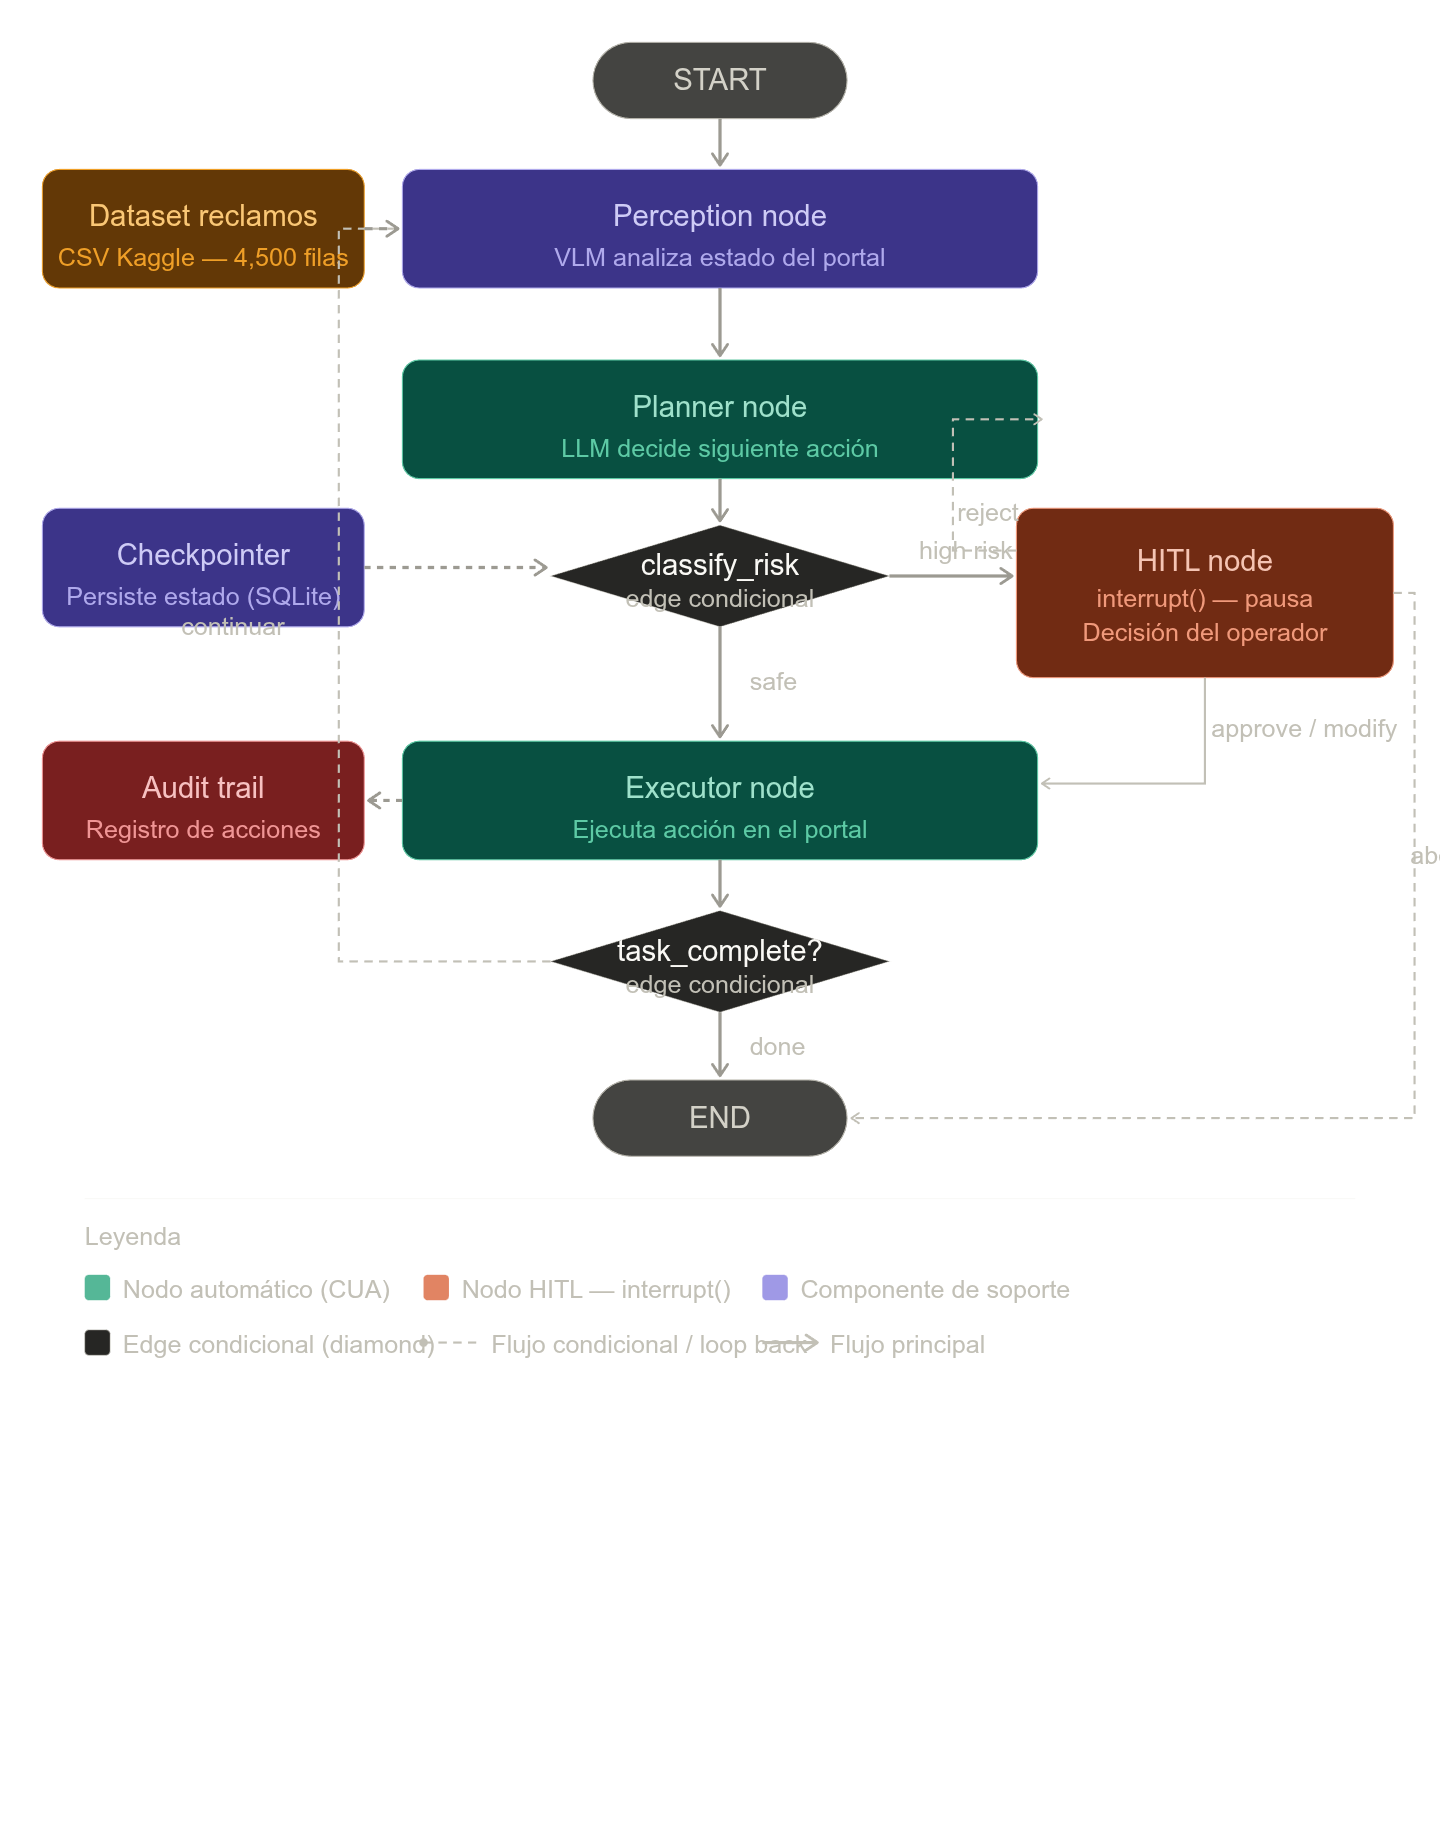

Nodo/Componente:
|Nodo/Componente|Tipo|Función|Descripción|
|:--------------|:---|:------|:----------|
|START|Punto de entrada|Iniciar el grafo|Recibe el estado inicial con los datos del reclamo del dataset de Kaggle (claim_id, monto, diagnóstico, risk_level).|
|perception_node|Nodo LLM (VLM)|Percibir el estado del portal|Simula la visión del agente sobre la UI del portal de seguros. En producción recibe screenshot base64 y usa Claude con visión. Produce una descripción textual del estado actual (elementos, botones, alertas).|
|planner_node|Nodo LLM (planner)|Decidir la siguiente acción|El LLM razona sobre el estado percibido, el historial de acciones y la razón de rechazo anterior (si existe), y genera una acción propuesta en JSON con su risk_level.|
|classify_risk|Edge condicional|Clasificar el riesgo de la acción|Inspecciona proposed_action.risk_level y el nombre de la acción. Si está en HIGH_RISK_PORTAL_ACTIONS o es una acción final en reclamo de alto riesgo, enruta a hitl; si no, a executor.|
|hitl_approval_node|Nodo HITL — interrupt()|Pausar y solicitar aprobación humana|Serializa el estado completo en el checkpointer y suspende el grafo. Presenta al operador los datos del reclamo, la acción propuesta y las opciones: approve, reject, modify, abort. Retoma con Command(resume=...).|
|executor_node|Nodo de ejecución (RPA)|Ejecutar la acción aprobada en el portal|Registra la acción en el audit trail (executed_by: human_approved o auto), determina si es una acción final (confirm_approval, confirm_rejection) y actualiza task_complete. En producción usa Playwright.|
|check_task_complete|Edge condicional|Decidir si continuar o terminar|Si task_complete = True enruta a END; si no, regresa a perception_node para el siguiente ciclo de observación.|
|END|Punto de salida|Finalizar el procesamiento|Termina el grafo con la decisión final del reclamo: approved, rejected, fraud_investigation o aborted.|
|MemorySaver/SqliteSaver|Checkpointer (persistencia)|Persistir el estado entre interrupciones|Almacena el ClaimCUAState completo en cada paso. Imprescindible para que interrupt() funcione y el operador pueda reanudar minutos después sin perder contexto.|
|ClaimCUAState|TypedDict (estado)|Transportar el estado a través del grafo|Contiene: claim_data, risk_level, portal_state, proposed_action, action_history, task_complete, final_decision, rejection_reason, operator_notes.|
|HIGH_RISK_PORTAL_ACTIONS|Conjunto de constantes|Definir el umbral de riesgo|Lista explícita de acciones que siempre requieren HITL: confirm_approval, confirm_rejection, submit_partial_payment, escalate_to_fraud, etc.|
|Dataset de reclamos|Fuente de datos externa|Proveer los reclamos a procesar|CSV de Kaggle (enhanced-health-insurance-claims-dataset, 4,500 filas) con campos de monto, diagnóstico ICD, estado y póliza. Alimenta el estado inicial de cada ejecución.|
|Audit trail|Componente de observabilidad|Registrar todas las acciones con trazabilidad|Lista de dicts en action_history con: acción, resultado, timestamp, executed_by (auto o human_approved) y notas del operador. Persiste en el checkpointer.|
|simulate_portal_state|Helper/mock del CUA|Simular el estado visual del portal|En el notebook reemplaza a Playwright + screenshot. Genera una descripción textual del portal según el historial de acciones ejecutadas. En producción se elimina.|




### Anti-patrones a evitar

| Anti-patrón | Problema | Solución |
|---|---|---|
| **HITL en cada acción** | Latencia inaceptable, operador se satura | Clasificar explícitamente `HIGH_RISK_ACTIONS` |
| **Sin audit trail** | No hay trazabilidad de quién aprobó qué | Registrar cada aprobación en el checkpointer con timestamp |
| **CUA sin sandbox** | Una acción errónea afecta producción directamente | Usar siempre VM aislada o sandbox de browser |
| **Timeout infinito en interrupt()** | El workflow queda bloqueado si el operador no responde | Configurar timeout con acción por defecto (abort) |
| **Mostrar solo JSON al operador** | Contexto insuficiente para tomar la decisión | Incluir screenshot actual + historial en el interrupt payload |
| **`HIGH_RISK_ACTIONS` vacío** | Todas las acciones se ejecutan sin supervisión | Tratar todo como alto riesgo si no está en la lista explícita |





### Cuándo usarlo
- ✅ Automatización de portales bancarios o de salud con acciones irreversibles frecuentes
- ✅ RPA inteligente en sistemas sin API donde los errores tienen costo real
- ✅ Flujos de aprobación que ya requieren revisión humana por normativa o compliance
- ✅ Agentes de soporte que gestionan UI pero deben escalar confirmaciones al operador
- ✅ Cualquier escenario CUA en producción donde "actuar y pedir perdón" no es aceptable
- ❌ Tareas de bajo riesgo completamente reversibles (el HITL introduce latencia innecesaria)
- ❌ Workflows de alta frecuencia donde la aprobación humana es un cuello de botella operativo

Reglas de producción para CUA + HITL
* Sandbox siempre — ejecutar el CUA en VM aislada; nunca conectar directamente a producción.
* HIGH_RISK_ACTIONS explícito — cualquier acción no listada debe tratarse como alto riesgo por defecto.
* Audit trail completo — registrar en el checkpointer: thread_id, timestamp, acción propuesta y decisión del operador.
* Timeout configurado — si el operador no responde en N minutos, escalar o abortar automáticamente.
* Screenshot en el payload del interrupt — mostrar al operador el estado visual actual, no solo el JSON de la acción.

In [1]:
!uv pip install -q langgraph langchain langchain-anthropic \
               langchain-community pandas matplotlib seaborn \
               kaggle ipywidgets

In [2]:
from dotenv import load_dotenv
load_dotenv()

True

###  Descargar el dataset desde Kaggle

In [3]:
# ─── CELDA 2: Descarga del dataset ───────────────────────────────────────────
# Requiere kaggle.json con tus credenciales en ~/.kaggle/kaggle.json
# O setear variables de entorno:
import os
# os.environ["KAGGLE_USERNAME"] = "tu_usuario"
# os.environ["KAGGLE_KEY"]      = "tu_api_key"

# Descarga
!kaggle datasets download -d leandrenash/enhanced-health-insurance-claims-dataset \
       --unzip -p ./data/

# Verificar archivo
import pathlib
files = list(pathlib.Path("./data").glob("*.csv"))
print("Archivos descargados:", files)

Dataset URL: https://www.kaggle.com/datasets/leandrenash/enhanced-health-insurance-claims-dataset
License(s): CC0-1.0
100%|█████████████████████████████████████████| 464k/464k [00:00<00:00, 627kB/s]

Archivos descargados: [PosixPath('data/word_embeddings.csv'), PosixPath('data/supervisor_results.csv'), PosixPath('data/enhanced_health_insurance_claims.csv'), PosixPath('data/customer_support_tickets.csv'), PosixPath('data/loan_approval_dataset.csv')]


### Exploración del dataset

In [4]:
# ─── CELDA 3: Exploración del dataset ────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el CSV (el nombre puede variar; ajústalo si es distinto)
df = pd.read_csv("./data/enhanced_health_insurance_claims.csv")

print("=" * 60)
print(f"Shape: {df.shape}")
print("=" * 60)
print("\nColumnas disponibles:")
print(df.dtypes)
print("\nPrimeras 3 filas:")
df.head(3)

Shape: (4500, 17)

Columnas disponibles:
ClaimID                     object
PatientID                   object
ProviderID                  object
ClaimAmount                float64
ClaimDate                   object
DiagnosisCode               object
ProcedureCode               object
PatientAge                   int64
PatientGender               object
ProviderSpecialty           object
ClaimStatus                 object
PatientIncome              float64
PatientMaritalStatus        object
PatientEmploymentStatus     object
ProviderLocation            object
ClaimType                   object
ClaimSubmissionMethod       object
dtype: object

Primeras 3 filas:


,ClaimID,PatientID,ProviderID,ClaimAmount,ClaimDate,DiagnosisCode,ProcedureCode,PatientAge,PatientGender,ProviderSpecialty,ClaimStatus,PatientIncome,PatientMaritalStatus,PatientEmploymentStatus,ProviderLocation,ClaimType,ClaimSubmissionMethod
0,10944daf-f7d5-4e1d-8216-72ffa609fe41,8552381d-7960-4f64-b190-b20b8ada00a1,4a4cb19c-4863-41cf-84b0-c2b21aace988,3807.95,2024-06-07,yy006,hd662,16,M,Cardiology,Pending,90279.43,Married,Retired,Jameshaven,Routine,Paper
1,fcbebb25-fc24-4c0f-a966-749edcf83fb1,327f43ad-e3bd-4473-a9ed-46483a0a156f,422e02dd-c1fd-43dd-8af4-0c3523f997b1,9512.07,2023-05-30,tD052,mH831,27,M,Pediatrics,Approved,130448.02,Single,Student,Beltrantown,Routine,Online
2,9e9983e7-9ea7-45f5-84d8-ce49ccd8a4a1,6f3acdf7-73aa-4afa-9c2e-b25b27bdb5b0,f7733b3f-0980-47b5-a7a0-ee390869355b,7346.74,2022-09-27,zx832,dg637,40,F,Cardiology,Pending,82417.54,Divorced,Employed,West Charlesport,Emergency,Online


### Preparar columnas de riesgo

In [5]:
# ─── CELDA 4 (ROBUSTA): Auto-detección de columnas clave ─────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import re

df = pd.read_csv("./data/enhanced_health_insurance_claims.csv")

print("Columnas disponibles en el dataset:")
for i, col in enumerate(df.columns):
    print(f"  [{i:02d}] {col:40s}  dtype={df[col].dtype}")

# ── Auto-detección por patrones de nombre ─────────────────────────────────────
def find_col(patterns: list[str], cols: list[str]) -> str | None:
    """Busca la primera columna cuyo nombre contenga alguno de los patrones (case-insensitive)."""
    for pat in patterns:
        for col in cols:
            if re.search(pat, col, re.IGNORECASE):
                return col
    return None

cols = list(df.columns)

CLAIM_AMOUNT_COL = find_col(
    [r"amount", r"charge", r"cost", r"total", r"billed", r"monto", r"value"],
    cols
)
DIAGNOSIS_COL = find_col(
    [r"diagnos", r"icd", r"disease", r"condition", r"code"],
    cols
)
STATUS_COL = find_col(
    [r"status", r"state", r"approval", r"result", r"outcome", r"decision"],
    cols
)
CLAIM_ID_COL = find_col(
    [r"claim_id", r"id", r"claim_num", r"reference"],
    cols
)

# Fallbacks: si no se detecta, usar la primera columna numérica / primera columna
if not CLAIM_AMOUNT_COL:
    numeric_cols = df.select_dtypes(include="number").columns.tolist()
    CLAIM_AMOUNT_COL = numeric_cols[0] if numeric_cols else cols[0]
    print(f"\n⚠️  No se detectó columna de monto. Usando fallback: '{CLAIM_AMOUNT_COL}'")

if not DIAGNOSIS_COL:
    DIAGNOSIS_COL = cols[1] if len(cols) > 1 else cols[0]
    print(f"⚠️  No se detectó columna de diagnóstico. Usando fallback: '{DIAGNOSIS_COL}'")

if not STATUS_COL:
    STATUS_COL = cols[2] if len(cols) > 2 else cols[0]
    print(f"⚠️  No se detectó columna de estado. Usando fallback: '{STATUS_COL}'")

if not CLAIM_ID_COL:
    CLAIM_ID_COL = cols[0]
    print(f"⚠️  No se detectó columna de ID. Usando fallback: '{CLAIM_ID_COL}'")

print(f"\n✅ Columnas detectadas:")
print(f"   CLAIM_ID_COL     = '{CLAIM_ID_COL}'")
print(f"   CLAIM_AMOUNT_COL = '{CLAIM_AMOUNT_COL}'")
print(f"   DIAGNOSIS_COL    = '{DIAGNOSIS_COL}'")
print(f"   STATUS_COL       = '{STATUS_COL}'")

# ── Verificar que los valores tienen sentido ──────────────────────────────────
print(f"\n  Muestra de {CLAIM_AMOUNT_COL}: {df[CLAIM_AMOUNT_COL].dropna().head(3).tolist()}")
print(f"  Muestra de {DIAGNOSIS_COL}:    {df[DIAGNOSIS_COL].dropna().head(3).tolist()}")
print(f"  Muestra de {STATUS_COL}:       {df[STATUS_COL].dropna().head(3).tolist()}")

Columnas disponibles en el dataset:
  [00] ClaimID                                   dtype=object
  [01] PatientID                                 dtype=object
  [02] ProviderID                                dtype=object
  [03] ClaimAmount                               dtype=float64
  [04] ClaimDate                                 dtype=object
  [05] DiagnosisCode                             dtype=object
  [06] ProcedureCode                             dtype=object
  [07] PatientAge                                dtype=int64
  [08] PatientGender                             dtype=object
  [09] ProviderSpecialty                         dtype=object
  [10] ClaimStatus                               dtype=object
  [11] PatientIncome                             dtype=float64
  [12] PatientMaritalStatus                      dtype=object
  [13] PatientEmploymentStatus                   dtype=object
  [14] ProviderLocation                          dtype=object
  [15] ClaimType                 

### Clasificar riesgo (ejecutar después de la detección)

In [6]:
# ─── CELDA 4b (AJUSTADA AL DATASET REAL): Clasificar riesgo ──────────────────

# Umbrales ajustados: el dataset va de $100 a $9,997
HIGH_RISK_THRESHOLD   = 7_000   # ~15% de los reclamos serán high
MEDIUM_RISK_THRESHOLD = 3_500   # ~50% medium, ~35% low

# El dataset usa códigos propios (yy006, tD052...) — clasificamos por prefijo/patrón
# Los que empiezan con letra mayúscula o ciertos prefijos los tratamos como "especiales"
import re

def is_high_risk_diagnosis(code: str) -> bool:
    """
    Heurística para códigos del dataset sintético:
    - Códigos que empiezan con mayúscula (ej: tD052, zA...) → riesgo alto
    - Códigos con dígitos iniciales pequeños (ej: 00x, 01x) → riesgo alto
    """
    code = str(code).strip()
    if len(code) < 3:
        return False
    # Tiene alguna mayúscula en los primeros 3 chars → alto riesgo
    if any(c.isupper() for c in code[:3]):
        return True
    # Empieza con 00 o 01
    if re.match(r'^0[01]', code):
        return True
    return False

def classify_claim_risk(row: pd.Series) -> str:
    amount = float(row.get(CLAIM_AMOUNT_COL, 0))
    diag   = str(row.get(DIAGNOSIS_COL, ""))

    if amount >= HIGH_RISK_THRESHOLD or is_high_risk_diagnosis(diag):
        return "high"
    elif amount >= MEDIUM_RISK_THRESHOLD:
        return "medium"
    return "low"

df[CLAIM_AMOUNT_COL] = pd.to_numeric(df[CLAIM_AMOUNT_COL], errors="coerce").fillna(0)
df["risk_level"] = df.apply(classify_claim_risk, axis=1)

# Generar claim_id legible si es necesario
if df[CLAIM_ID_COL].dtype in ["int64", "float64"]:
    df[CLAIM_ID_COL] = df[CLAIM_ID_COL].apply(lambda x: f"CLM-{int(x):05d}")

risk_dist = df["risk_level"].value_counts()
print("Distribución de riesgo (umbrales ajustados):")
print(risk_dist)
print(f"\nEjemplos de reclamos HIGH RISK:")
print(df[df["risk_level"] == "high"][[CLAIM_ID_COL, CLAIM_AMOUNT_COL, DIAGNOSIS_COL]].head(5).to_string())

Distribución de riesgo (umbrales ajustados):
risk_level
high      3736
medium     402
low        362
Name: count, dtype: int64

Ejemplos de reclamos HIGH RISK:
                                ClaimID  ClaimAmount DiagnosisCode
1  fcbebb25-fc24-4c0f-a966-749edcf83fb1      9512.07         tD052
2  9e9983e7-9ea7-45f5-84d8-ce49ccd8a4a1      7346.74         zx832
4  f702a717-254b-4cff-a0c7-8395db2f6616      1644.58         LZ261
5  78657d24-a96e-461d-970b-d54329d9ceff      1644.35         qM187
6  5e2751ed-c6af-44ed-b95d-c91a19784c9e       675.03         tZ864


### Configuración del entorno

In [7]:
# ── Patch compatibilidad: langchain-core vs paquete `langchain` ───────────────
# langchain-core consulta globals (verbose/debug/llm_cache) en el módulo `langchain`.
# Si esa versión no los expone -> AttributeError ("module 'langchain' has no
# attribute 'verbose'"). Ejecuta esta celda ANTES de instanciar ChatAnthropic.
import langchain
import langchain_core.globals as _lcg
for _attr, _default in (("verbose", False), ("debug", False), ("llm_cache", None)):
    if not hasattr(langchain, _attr):
        setattr(langchain, _attr, _default)
for _name, _fb in (("get_verbose", False), ("get_llm_cache", None)):
    _orig = getattr(_lcg, _name, None)
    if _orig is not None:
        def _make(orig, fb):
            def _patched():
                try:
                    return orig()
                except AttributeError:
                    return fb
            return _patched
        setattr(_lcg, _name, _make(_orig, _fb))
print("✅ patch compatibilidad langchain aplicado")


✅ patch compatibilidad langchain aplicado


In [8]:
# ─── CELDA 5: Configuración del entorno ──────────────────────────────────────
import os
import json
import re
import sqlite3
from typing import TypedDict, Literal, Optional, Any
from datetime import datetime

# API Key de Anthropic (usa variable de entorno en producción)
#os.environ["ANTHROPIC_API_KEY"] = "sk-ant-..."  # ← reemplaza con tu key

# Imports LangGraph + LangChain
from langchain_anthropic import ChatAnthropic
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, BaseMessage
from langgraph.graph import StateGraph, START, END
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import MemorySaver  # InMemory para notebook

# LLM principal — claude-sonnet para producción; claude-haiku para demos rápidos
llm = ChatAnthropic(
    model="claude-sonnet-4-5",   # ó "claude-haiku-4-5" para mayor velocidad
    temperature=0,
    max_tokens=1024,
)

print("✅ Entorno configurado correctamente")
print(f"   Modelo: {llm.model}")

✅ Entorno configurado correctamente
   Modelo: claude-sonnet-4-5


/home/ernesto/PycharmProjects/Langgraph_tutorials/.venv/lib/python3.13/site-packages/langgraph/checkpoint/base/__init__.py:18: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


### Definición del State y acciones de riesgo

In [9]:
# ─── CELDA 6: State del agente CUA + HITL ────────────────────────────────────

class ClaimCUAState(TypedDict):
    """Estado completo del agente CUA + HITL para procesamiento de reclamos."""

    # Datos del reclamo actual
    claim_id:           str
    claim_data:         dict                    # fila completa del DataFrame
    risk_level:         str                     # 'low' | 'medium' | 'high'

    # Estado del agente
    messages:           list[BaseMessage]       # historial de mensajes
    portal_state:       str                     # descripción textual del portal (simula screenshot)
    proposed_action:    Optional[dict]          # acción propuesta por el planner
    action_history:     list[dict]              # registro de todas las acciones ejecutadas

    # Control de flujo
    task_complete:      bool
    final_decision:     Optional[str]           # 'approved' | 'rejected' | 'pending_review'
    rejection_reason:   Optional[str]           # si el operador rechazó una acción propuesta
    operator_notes:     Optional[str]           # notas del operador para el registro de auditoría

# ── Acciones de ALTO RIESGO — siempre requieren aprobación humana ────────────
HIGH_RISK_PORTAL_ACTIONS = {
    "confirm_approval",      # confirmar aprobación del reclamo
    "confirm_rejection",     # confirmar rechazo del reclamo
    "submit_partial_payment",# pago parcial
    "escalate_to_fraud",     # escalar a investigación de fraude
    "request_additional_docs",# solicitar documentación adicional al asegurado
    "override_system_decision",# anular decisión automática del sistema
}

# ── Acciones SEGURAS — el CUA las ejecuta sin intervención humana ─────────────
SAFE_PORTAL_ACTIONS = {
    "navigate_to_claim",     # navegar al formulario del reclamo
    "read_claim_details",    # leer detalles del reclamo en el portal
    "check_policy_status",   # verificar estado de la póliza
    "search_claim_history",  # buscar historial del asegurado
    "download_documents",    # descargar documentos adjuntos
}

print("✅ State y clasificación de acciones definidos")
print(f"   Acciones de alto riesgo (HITL): {len(HIGH_RISK_PORTAL_ACTIONS)}")
print(f"   Acciones seguras (auto): {len(SAFE_PORTAL_ACTIONS)}")

✅ State y clasificación de acciones definidos
   Acciones de alto riesgo (HITL): 6
   Acciones seguras (auto): 5


### Simulador del portal web (mock del CUA)

In [10]:
# ─── CELDA 7: Simulador del portal web de la aseguradora ─────────────────────
# En producción real: esto se reemplaza por Playwright + create_cua()
# Aquí simulamos el "estado del portal" para el notebook.

def simulate_portal_state(claim_data: dict, action_history: list[dict]) -> str:
    """
    Simula lo que el VLM percibiría en el screenshot del portal.
    Retorna una descripción textual del estado actual de la UI.
    """
    claim_id   = claim_data.get(CLAIM_ID_COL, "CLM-0001")
    amount     = claim_data.get(CLAIM_AMOUNT_COL, 0)
    diagnosis  = claim_data.get(DIAGNOSIS_COL, "N/A")
    status     = claim_data.get(STATUS_COL, "Pending")

    last_action = action_history[-1]["action"] if action_history else "none"

    # Simular diferentes vistas del portal según el historial
    if last_action == "none":
        return (
            f"PORTAL ESTADO: Dashboard de reclamos pendientes.\n"
            f"Reclamo seleccionado: {claim_id}\n"
            f"Botones disponibles: [Ver Detalles] [Historial] [Buscar Póliza]"
        )
    elif last_action in ("navigate_to_claim", "read_claim_details"):
        risk_flag = "⚠️ MONTO ELEVADO" if float(amount) >= HIGH_RISK_THRESHOLD else ""
        return (
            f"PORTAL ESTADO: Formulario de detalle del reclamo.\n"
            f"ID: {claim_id} | Monto: ${float(amount):,.2f} {risk_flag}\n"
            f"Diagnóstico: {diagnosis} | Estado actual: {status}\n"
            f"Póliza: ACTIVA | Cobertura máxima: $50,000\n"
            f"Documentos adjuntos: Sí (3 archivos)\n"
            f"Botones disponibles: [Aprobar] [Rechazar] [Solicitar Docs] [Escalar Fraude]"
        )
    elif last_action == "check_policy_status":
        return (
            f"PORTAL ESTADO: Información de póliza.\n"
            f"Asegurado: ID-{claim_data.get('patient_id', 'P001')} | Póliza: VIGENTE\n"
            f"Historial: 0 fraudes detectados | Reclamos previos: 2 (aprobados)\n"
            f"Botones disponibles: [Volver al Reclamo] [Ver Historial Completo]"
        )
    else:
        return (
            f"PORTAL ESTADO: Acción '{last_action}' ejecutada.\n"
            f"Reclamo {claim_id} — esperando confirmación final.\n"
            f"Botones disponibles: [Confirmar] [Cancelar]"
        )

print("✅ Simulador del portal definido")

✅ Simulador del portal definido


### Nodo de Percepción (VLM)

In [11]:
# ─── CELDA 8: Nodo 1 — Percepción del estado del portal ─────────────────────

def perception_node(state: ClaimCUAState) -> dict:
    """
    Simula la percepción VLM: el agente 've' el estado del portal
    y genera una interpretación estructurada.

    En producción: recibe screenshot base64 y usa Claude claude-opus-4-6 con vision.
    En el notebook: usa la descripción textual del portal simulado.
    """
    portal_state = simulate_portal_state(
        state["claim_data"],
        state.get("action_history", [])
    )

    perception_prompt = f"""Eres un agente de percepción para un portal de seguros médicos.

Estado actual del portal:
{portal_state}

Reclamo en proceso:
- ID: {state['claim_id']}
- Monto: ${float(state['claim_data'].get(CLAIM_AMOUNT_COL, 0)):,.2f}
- Diagnóstico: {state['claim_data'].get(DIAGNOSIS_COL, 'N/A')}
- Nivel de riesgo clasificado: {state['risk_level']}

Describe brevemente:
1. Qué elementos interactivos están disponibles
2. Cuál es el estado actual del proceso
3. Si hay alertas o indicadores de riesgo visibles"""

    response = llm.invoke([HumanMessage(content=perception_prompt)])

    return {
        "portal_state": portal_state,
        "messages": state.get("messages", []) + [
            HumanMessage(content=perception_prompt),
            AIMessage(content=response.content)
        ],
    }

print("✅ Nodo de percepción definido")

✅ Nodo de percepción definido


### Nodo Planner (toma de decisiones)

In [12]:
# ─── CELDA 9: Nodo 2 — Action Planner ───────────────────────────────────────

def planner_node(state: ClaimCUAState) -> dict:
    """
    El LLM decide la siguiente acción basándose en:
    - Estado percibido del portal
    - Datos del reclamo (monto, diagnóstico, historial)
    - Acciones ya ejecutadas
    - Razón de rechazo del operador (si hubo)
    """
    history_summary = "\n".join([
        f"  [{i+1}] {a['action']} → {a.get('result', 'OK')} (por: {a.get('executed_by','auto')})"
        for i, a in enumerate(state.get("action_history", [])[-5:])
    ]) or "  (ninguna acción ejecutada aún)"

    rejection_ctx = ""
    if state.get("rejection_reason"):
        rejection_ctx = (
            f"\n⚠️ ACCIÓN ANTERIOR RECHAZADA POR EL OPERADOR.\n"
            f"Motivo: {state['rejection_reason']}\n"
            f"Propón una acción alternativa o más granular.\n"
        )

    planner_prompt = f"""Eres un planificador de acciones para procesar reclamos de seguro médico.

RECLAMO ACTUAL:
- ID: {state['claim_id']}
- Monto reclamado: ${float(state['claim_data'].get(CLAIM_AMOUNT_COL, 0)):,.2f}
- Código de diagnóstico: {state['claim_data'].get(DIAGNOSIS_COL, 'N/A')}
- Estado en sistema: {state['claim_data'].get(STATUS_COL, 'Pending')}
- Nivel de riesgo: {state['risk_level'].upper()}

ESTADO ACTUAL DEL PORTAL:
{state.get('portal_state', 'No disponible')}

ACCIONES YA EJECUTADAS:
{history_summary}
{rejection_ctx}

Decide la ÚNICA siguiente acción más apropiada.
Responde SOLO con JSON válido, sin markdown:
{{
  "action": "<nombre_de_accion>",
  "target": "<elemento_ui_o_selector>",
  "value": "<valor_si_aplica_o_null>",
  "reason": "<justificacion_breve>",
  "risk_level": "safe|moderate|high",
  "is_final_action": true_o_false
}}

Acciones disponibles (safe): {list(SAFE_PORTAL_ACTIONS)}
Acciones de alto riesgo (requieren HITL): {list(HIGH_RISK_PORTAL_ACTIONS)}

Si ya tienes suficiente información para tomar una decisión final, propón confirm_approval o confirm_rejection."""

    response = llm.invoke([HumanMessage(content=planner_prompt)])

    # Parsear el JSON de la respuesta
    try:
        match = re.search(r"\{[^{}]*\}", response.content, re.DOTALL)
        proposed = json.loads(match.group()) if match else {
            "action": "read_claim_details",
            "risk_level": "safe",
            "reason": "Acción por defecto: leer detalles del reclamo",
            "is_final_action": False,
        }
    except (json.JSONDecodeError, AttributeError):
        proposed = {
            "action": "read_claim_details",
            "risk_level": "safe",
            "reason": "Fallback: error en parsing del planner",
            "is_final_action": False,
        }

    print(f"  📋 Planner propone: {proposed['action']} (riesgo: {proposed['risk_level']})")

    return {
        "proposed_action": proposed,
        "rejection_reason": None,   # limpiar rechazo anterior
    }

print("✅ Nodo planner definido")

✅ Nodo planner definido


### Clasificador de riesgo (edge condicional)

In [13]:
# ─── CELDA 10: Edge condicional — Risk Classifier ────────────────────────────

def classify_risk(state: ClaimCUAState) -> Literal["hitl", "executor", "end"]:
    """
    Decide el routing basándose en el nivel de riesgo de la acción propuesta.

    Reglas:
    - Acción de alto riesgo → hitl (aprobación humana)
    - Tarea completa → end
    - Caso contrario → executor (ejecución automática)
    """
    if state.get("task_complete"):
        return "end"

    action = state.get("proposed_action", {})
    action_name  = action.get("action", "")
    risk_declared = action.get("risk_level", "high")

    # Alto riesgo si: está en la lista explícita O el planner lo declaró como high
    is_high_risk = (
        action_name in HIGH_RISK_PORTAL_ACTIONS
        or risk_declared == "high"
        or (state["risk_level"] == "high" and action.get("is_final_action", False))
    )

    if is_high_risk:
        print(f"  🔴 Acción de ALTO RIESGO detectada → requiere HITL")
        return "hitl"

    print(f"  🟢 Acción SEGURA → ejecución automática")
    return "executor"

print("✅ Clasificador de riesgo definido")

✅ Clasificador de riesgo definido


### Nodo HITL con interrupt()

In [14]:
# ─── CELDA 11: Nodo HITL — Human-in-the-Loop con interrupt() ─────────────────

def hitl_approval_node(state: ClaimCUAState):
    """
    Pausa el flujo y presenta la acción propuesta al operador.
    El operador puede: approve | reject | modify | abort

    interrupt() serializa el estado completo en el checkpointer
    y retorna el control al operador hasta que se llame Command(resume=...).
    """
    action     = state["proposed_action"]
    claim_data = state["claim_data"]
    amount     = float(claim_data.get(CLAIM_AMOUNT_COL, 0))

    # Construir el payload completo para el operador
    interrupt_payload = {
        "tipo":            "APROBACIÓN_REQUERIDA",
        "timestamp":       datetime.now().isoformat(),
        "claim_id":        state["claim_id"],
        "nivel_riesgo":    state["risk_level"].upper(),

        "datos_reclamo": {
            "monto_reclamado": f"${amount:,.2f}",
            "diagnostico":     claim_data.get(DIAGNOSIS_COL, "N/A"),
            "estado_actual":   claim_data.get(STATUS_COL, "Pending"),
        },

        "accion_propuesta": {
            "nombre":       action.get("action"),
            "objetivo_ui":  action.get("target", "N/A"),
            "valor":        action.get("value"),
            "justificacion": action.get("reason"),
        },

        "acciones_previas": len(state.get("action_history", [])),
        "estado_portal":    state.get("portal_state", "")[:300] + "...",

        "advertencia": (
            "⚠️ Esta acción es IRREVERSIBLE y tiene impacto financiero. "
            "Verifica los datos antes de aprobar."
        ),

        "opciones_disponibles": {
            "approve": "Ejecutar la acción tal como está propuesta",
            "reject":  "Rechazar — incluir campo 'reason' con el motivo",
            "modify":  "Aprobar con cambios — incluir campo 'modified_action' (JSON)",
            "abort":   "Cancelar todo el procesamiento de este reclamo",
        },
    }

    print("\n" + "="*60)
    print("⏸  HITL INTERRUPT — ESPERANDO APROBACIÓN DEL OPERADOR")
    print("="*60)
    print(f"  Reclamo: {state['claim_id']}")
    print(f"  Acción propuesta: {action.get('action')}")
    print(f"  Monto en juego: ${amount:,.2f}")
    print(f"  Justificación: {action.get('reason')}")
    print("="*60)

    # ← PAUSA AQUÍ: el grafo se suspende hasta Command(resume=...)
    decision = interrupt(interrupt_payload)

    operator_action = decision.get("action", "reject")

    if operator_action == "approve":
        print(f"  ✅ Operador APROBÓ la acción")
        return Command(
            update={"operator_notes": decision.get("notes", "Aprobado sin observaciones")},
            goto="executor"
        )

    elif operator_action == "modify":
        modified = decision.get("modified_action", action)
        print(f"  ✏️  Operador MODIFICÓ la acción: {modified.get('action')}")
        return Command(
            update={
                "proposed_action": modified,
                "operator_notes":  decision.get("notes", ""),
            },
            goto="executor"
        )

    elif operator_action == "abort":
        print(f"  🚫 Operador ABORTÓ el procesamiento")
        return Command(
            update={
                "task_complete":  True,
                "final_decision": "aborted",
                "operator_notes": decision.get("notes", "Cancelado por operador"),
                "messages": state.get("messages", []) + [
                    AIMessage(content=f"Reclamo {state['claim_id']} cancelado por decisión del operador.")
                ],
            },
            goto=END
        )

    else:  # reject
        reason = decision.get("reason", "Rechazado sin motivo especificado")
        print(f"  ❌ Operador RECHAZÓ la acción. Motivo: {reason}")
        return Command(
            update={"rejection_reason": reason},
            goto="planner"
        )

print("✅ Nodo HITL definido")

✅ Nodo HITL definido


###  Nodo Executor

In [15]:
# ─── CELDA 12: Nodo Executor — ejecuta la acción en el portal ────────────────

MAX_ACTIONS = 6  # límite de seguridad para evitar loops infinitos

def executor_node(state: ClaimCUAState) -> dict:
    action      = state["proposed_action"]
    action_name = action.get("action", "unknown")
    history     = state.get("action_history", [])

    # Determinar si esta acción cierra el flujo
    FINAL_ACTIONS = {"confirm_approval", "confirm_rejection",
                     "escalate_to_fraud", "task_complete", "confirm_success"}

    is_final = (
        action.get("is_final_action", False)
        or action_name in FINAL_ACTIONS
        or len(history) >= MAX_ACTIONS - 1   # ← límite de seguridad
    )

    # Determinar decisión final
    final_decision = state.get("final_decision")
    if action_name == "confirm_approval":
        final_decision = "approved"
    elif action_name == "confirm_rejection":
        final_decision = "rejected"
    elif action_name == "escalate_to_fraud":
        final_decision = "fraud_investigation"
    elif len(history) >= MAX_ACTIONS - 1:
        final_decision = "max_actions_reached"

    audit_entry = {
        "action":         action_name,
        "target":         action.get("target", ""),
        "value":          action.get("value", ""),
        "result":         f"Ejecutado exitosamente — {action_name}",
        "executed_by":    "human_approved" if state.get("operator_notes") else "auto",
        "timestamp":      datetime.now().isoformat(),
        "operator_notes": state.get("operator_notes"),
    }

    print(f"  ⚡ Ejecutando: {action_name} "
          f"{'(aprobado por operador)' if state.get('operator_notes') else '(auto)'}")
    if is_final:
        print(f"  🏁 Acción final — cerrando flujo")

    return {
        "action_history":  history + [audit_entry],
        "proposed_action": None,
        "task_complete":   is_final,
        "final_decision":  final_decision,
        "operator_notes":  None,
    }

def check_task_complete(state: ClaimCUAState) -> Literal["perception", "end"]:
    """Edge: ¿se completó la tarea?"""
    if state.get("task_complete"):
        print(f"\n✅ Tarea completada. Decisión final: {state.get('final_decision', 'N/A').upper()}")
        return "end"
    return "perception"

print("✅ Nodo executor y edge de completitud definidos")

✅ Nodo executor y edge de completitud definidos


### Ensamblar el grafo

In [16]:
# ─── CELDA 13: Construcción y compilación del grafo CUA + HITL ───────────────

checkpointer = MemorySaver()  # InMemory para el notebook; SqliteSaver en producción

builder = StateGraph(ClaimCUAState)

# ── Registrar nodos ───────────────────────────────────────────────────────────
builder.add_node("perception", perception_node)
builder.add_node("planner",    planner_node)
builder.add_node("hitl",       hitl_approval_node)
builder.add_node("executor",   executor_node)

# ── Edges ─────────────────────────────────────────────────────────────────────
builder.add_edge(START,        "perception")
builder.add_edge("perception", "planner")

builder.add_conditional_edges(
    "planner",
    classify_risk,
    {
        "hitl":     "hitl",
        "executor": "executor",
        "end":      END,
    }
)

builder.add_conditional_edges(
    "executor",
    check_task_complete,
    {
        "perception": "perception",
        "end":        END,
    }
)
# Nota: hitl_approval_node usa Command(goto=...) internamente → no necesita add_edge

# ── Compilar ──────────────────────────────────────────────────────────────────
graph = builder.compile(checkpointer=checkpointer)

print("✅ Grafo compilado exitosamente")
print("\nNodos del grafo:", list(graph.nodes))

✅ Grafo compilado exitosamente

Nodos del grafo: ['__start__', 'perception', 'planner', 'hitl', 'executor']


### Visualizar el grafo

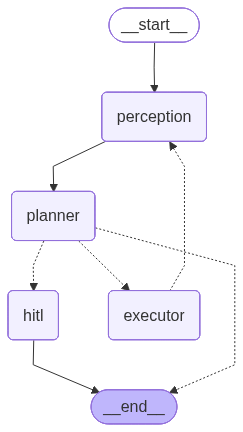

✅ Grafo renderizado


In [17]:
# ─── CELDA 14: Visualización del grafo ───────────────────────────────────────
try:
    from IPython.display import display, Image
    img = graph.get_graph().draw_mermaid_png()
    display(Image(img))
    print("✅ Grafo renderizado")
except Exception as e:
    # Fallback: mostrar el mermaid como texto
    print("Mermaid del grafo:")
    print(graph.get_graph().draw_mermaid())

### Función auxiliar de reporte

In [18]:
# ─── CELDA 15: Función auxiliar para reporte de auditoría ────────────────────

def print_audit_report(state: dict):
    """Genera un reporte de auditoría completo del procesamiento."""
    # Protección contra valores None en campos opcionales
    final_decision = state.get("final_decision") or "pending"
    risk_level     = state.get("risk_level") or "unknown"
    claim_data     = state.get("claim_data") or {}

    print("\n" + "="*65)
    print("📋 REPORTE DE AUDITORÍA — RECLAMO", state.get("claim_id", "N/A"))
    print("="*65)
    print(f"  Decisión final:   {final_decision.upper()}")
    print(f"  Nivel de riesgo:  {risk_level.upper()}")
    print(f"  Monto:            ${float(claim_data.get(CLAIM_AMOUNT_COL, 0)):,.2f}")
    print(f"  Total acciones ejecutadas: {len(state.get('action_history', []))}")

    hitl_count = sum(
        1 for a in state.get("action_history", [])
        if a.get("executed_by") == "human_approved"
    )
    print(f"  Acciones aprobadas por operador (HITL): {hitl_count}")

    print("\n  HISTORIAL DE ACCIONES:")
    for i, action in enumerate(state.get("action_history", []), 1):
        icon = "👤" if action.get("executed_by") == "human_approved" else "🤖"
        print(f"    {i}. {icon} {action['action']} — {action.get('result', 'OK')}")
        if action.get("operator_notes"):
            print(f"       📝 Nota: {action['operator_notes']}")
    print("="*65)

### Demo: Reclamo de BAJO riesgo (ejecución automática)

In [19]:
# ─── CELDA 16 (CORREGIDA): Demo 1 — Reclamo de BAJO RIESGO ──────────────────
print("🔵 DEMO 1: Reclamo de bajo riesgo — ejecución totalmente automática\n")

# Filtrar por datos válidos + risk_level correcto
def get_valid_sample(risk: str) -> pd.Series:
    mask = (
        (df["risk_level"] == risk) &
        (df[CLAIM_AMOUNT_COL] > 0) &
        (df[DIAGNOSIS_COL].notna()) &
        (df[DIAGNOSIS_COL].astype(str).str.strip().str.len() > 0)
    )
    subset = df[mask]
    if subset.empty:
        raise ValueError(f"No hay reclamos válidos con risk_level='{risk}'")
    return subset.iloc[0].to_dict()

low_risk_sample = get_valid_sample("low")

print(f"  Reclamo seleccionado: {low_risk_sample.get(CLAIM_ID_COL)}")
print(f"  Monto:      ${float(low_risk_sample.get(CLAIM_AMOUNT_COL, 0)):,.2f}")
print(f"  Diagnóstico: {low_risk_sample.get(DIAGNOSIS_COL)}")
print(f"  Estado:      {low_risk_sample.get(STATUS_COL)}\n")

initial_state_low = ClaimCUAState(
    claim_id         = str(low_risk_sample.get(CLAIM_ID_COL, "CLM-LOW-001")),
    claim_data       = low_risk_sample,
    risk_level       = "low",
    messages         = [],
    portal_state     = "",
    proposed_action  = None,
    action_history   = [],
    task_complete    = False,
    final_decision   = None,
    rejection_reason = None,
    operator_notes   = None,
)

config_low = {"configurable": {"thread_id": "demo-low-risk-001"}}

print("▶ Iniciando procesamiento automático...")
final_state_low = graph.invoke(initial_state_low, config_low)
print_audit_report(final_state_low)
print("\n✅ Procesamiento completado SIN intervención humana")

🔵 DEMO 1: Reclamo de bajo riesgo — ejecución totalmente automática

  Reclamo seleccionado: 89d0b0c0-7ccc-4ccb-b25a-b636967a2395
  Monto:      $3,112.00
  Diagnóstico: ry195
  Estado:      Denied

▶ Iniciando procesamiento automático...
  📋 Planner propone: read_claim_details (riesgo: safe)
  🟢 Acción SEGURA → ejecución automática
  ⚡ Ejecutando: read_claim_details (auto)
  📋 Planner propone: override_system_decision (riesgo: high)
  🔴 Acción de ALTO RIESGO detectada → requiere HITL

⏸  HITL INTERRUPT — ESPERANDO APROBACIÓN DEL OPERADOR
  Reclamo: 89d0b0c0-7ccc-4ccb-b25a-b636967a2395
  Acción propuesta: override_system_decision
  Monto en juego: $3,112.00
  Justificación: El reclamo fue denegado por el sistema pero cumple criterios de aprobación: póliza activa, monto dentro de cobertura ($3,112 < $50,000), documentos adjuntos completos (3 archivos), y nivel de riesgo LOW. Se requiere intervención humana para revertir la decisión automática.

📋 REPORTE DE AUDITORÍA — RECLAMO 89d0b0c0-7c

### Demo: Reclamo de ALTO riesgo con aprobación

In [20]:
# ─── CELDA 17: Demo 2 — Reclamo de ALTO RIESGO con HITL (aprobación) ────────
print("🔴 DEMO 2: Reclamo de alto riesgo — pausa + aprobación del operador\n")

# Seleccionar un reclamo de alto riesgo
high_risk_sample = get_valid_sample("high")

initial_state_high = ClaimCUAState(
    claim_id        = str(high_risk_sample.get(CLAIM_ID_COL, "CLM-HIGH-001")),
    claim_data      = high_risk_sample,
    risk_level      = "high",
    messages        = [],
    portal_state    = "",
    proposed_action = None,
    action_history  = [],
    task_complete   = False,
    final_decision  = None,
    rejection_reason = None,
    operator_notes  = None,
)

config_high = {"configurable": {"thread_id": "demo-high-risk-001"}}

# Paso 1: Iniciar — el grafo se detendrá en interrupt()
print("▶ Iniciando... El agente ejecutará acciones seguras y luego pausará en HITL")
try:
    result_step1 = graph.invoke(initial_state_high, config_high)
except Exception as e:
    # interrupt() lanza GraphInterrupt — esto es esperado y normal
    print(f"  ⏸ Grafo pausado en HITL (comportamiento esperado): {type(e).__name__}")

# Paso 2: Operador APRUEBA la acción
print("\n▶ Simulando aprobación del operador...")
final_state_high = graph.invoke(
    Command(resume={
        "action": "approve",
        "notes":  "Póliza vigente verificada. Documentos completos. Aprobado por médico revisor."
    }),
    config_high
)

print_audit_report(final_state_high)

🔴 DEMO 2: Reclamo de alto riesgo — pausa + aprobación del operador

▶ Iniciando... El agente ejecutará acciones seguras y luego pausará en HITL
  📋 Planner propone: read_claim_details (riesgo: safe)
  🟢 Acción SEGURA → ejecución automática
  ⚡ Ejecutando: read_claim_details (auto)
  📋 Planner propone: escalate_to_fraud (riesgo: high)
  🔴 Acción de ALTO RIESGO detectada → requiere HITL

⏸  HITL INTERRUPT — ESPERANDO APROBACIÓN DEL OPERADOR
  Reclamo: fcbebb25-fc24-4c0f-a966-749edcf83fb1
  Acción propuesta: escalate_to_fraud
  Monto en juego: $9,512.07
  Justificación: Reclamo clasificado como HIGH risk con código de diagnóstico sospechoso (tD052 - formato atípico con 't' prefijo), monto elevado ($9,512.07) y estado Approved que requiere validación. La combinación de factores de riesgo justifica escalamiento antes de confirmar aprobación.

▶ Simulando aprobación del operador...

⏸  HITL INTERRUPT — ESPERANDO APROBACIÓN DEL OPERADOR
  Reclamo: fcbebb25-fc24-4c0f-a966-749edcf83fb1
  Acción

### Demo: Rechazo del operador + re-planificación

In [21]:
# ─── CELDA 18: Demo 3 — HITL con RECHAZO y re-planificación del agente ───────
print("🔴 DEMO 3: El operador RECHAZA la acción → el agente re-planifica\n")

config_reject = {"configurable": {"thread_id": "demo-reject-001"}}

# Usar otro reclamo de alto riesgo
high_risk_sample2 = get_valid_sample("high")
high_risk_valids = df[
    (df["risk_level"] == "high") &
    (df[CLAIM_AMOUNT_COL] > 0) &
    (df[DIAGNOSIS_COL].notna())
]
high_risk_sample2 = high_risk_valids.iloc[1].to_dict() if len(high_risk_valids) > 1 else high_risk_valids.iloc[0].to_dict()

initial_state_reject = ClaimCUAState(
    claim_id        = str(high_risk_sample2.get(CLAIM_ID_COL, "CLM-HIGH-002")),
    claim_data      = high_risk_sample2,
    risk_level      = "high",
    messages        = [],
    portal_state    = "",
    proposed_action = None,
    action_history  = [],
    task_complete   = False,
    final_decision  = None,
    rejection_reason = None,
    operator_notes  = None,
)

# Paso 1: Iniciar
try:
    graph.invoke(initial_state_reject, config_reject)
except Exception:
    print("  ⏸ Primera pausa HITL activada")

# Paso 2: Operador RECHAZA con motivo
print("\n▶ Operador rechaza la acción propuesta con motivo...")
try:
    graph.invoke(
        Command(resume={
            "action": "reject",
            "reason": (
                "El diagnóstico Z51.11 (quimioterapia) requiere pre-autorización del "
                "oncólogo coordinador antes de aprobar. Solicitar documentación adicional primero."
            )
        }),
        config_reject
    )
except Exception:
    print("  ⏸ Segunda pausa HITL — el agente re-planificó y propone nueva acción")

# Paso 3: El agente re-planificó → operador aprueba la nueva acción
print("\n▶ El agente propone 'solicitar documentación adicional'. Operador aprueba...")
final_state_reject = graph.invoke(
    Command(resume={
        "action": "approve",
        "notes":  "Correcto. Solicitar pre-autorización al oncólogo coordinador."
    }),
    config_reject
)

print_audit_report(final_state_reject)

🔴 DEMO 3: El operador RECHAZA la acción → el agente re-planifica

  📋 Planner propone: read_claim_details (riesgo: safe)
  🟢 Acción SEGURA → ejecución automática
  ⚡ Ejecutando: read_claim_details (auto)
  📋 Planner propone: check_policy_status (riesgo: safe)
  🟢 Acción SEGURA → ejecución automática
  ⚡ Ejecutando: check_policy_status (auto)
  📋 Planner propone: escalate_to_fraud (riesgo: high)
  🔴 Acción de ALTO RIESGO detectada → requiere HITL

⏸  HITL INTERRUPT — ESPERANDO APROBACIÓN DEL OPERADOR
  Reclamo: 9e9983e7-9ea7-45f5-84d8-ce49ccd8a4a1
  Acción propuesta: escalate_to_fraud
  Monto en juego: $7,346.74
  Justificación: El reclamo presenta nivel de riesgo HIGH y código de diagnóstico zx832 que requiere validación especializada. Monto significativo de $7,346.74 justifica revisión por equipo de fraude antes de aprobar o rechazar.

▶ Operador rechaza la acción propuesta con motivo...

⏸  HITL INTERRUPT — ESPERANDO APROBACIÓN DEL OPERADOR
  Reclamo: 9e9983e7-9ea7-45f5-84d8-ce49ccd8

### Demo: Abort por el operador

In [22]:
# ─── CELDA 19: Demo 4 — Operador ABORTA el procesamiento ────────────────────
print("🚫 DEMO 4: El operador aborta el procesamiento (posible fraude detectado)\n")

config_abort = {"configurable": {"thread_id": "demo-abort-001"}}
high_risk_sample3 = high_risk_valids.iloc[2].to_dict() if len(high_risk_valids) > 2 else high_risk_valids.iloc[0].to_dict()


initial_state_abort = ClaimCUAState(
    claim_id        = str(high_risk_sample3.get(CLAIM_ID_COL, "CLM-HIGH-003")),
    claim_data      = high_risk_sample3,
    risk_level      = "high",
    messages        = [],
    portal_state    = "",
    proposed_action = None,
    action_history  = [],
    task_complete   = False,
    final_decision  = None,
    rejection_reason = None,
    operator_notes  = None,
)

try:
    graph.invoke(initial_state_abort, config_abort)
except Exception:
    print("  ⏸ HITL activado")

# Operador aborta con nota de auditoría
print("\n▶ Operador detecta inconsistencias y aborta...")
final_abort = graph.invoke(
    Command(resume={
        "action": "abort",
        "notes":  (
            "Reclamo suspendido. Detectada inconsistencia: "
            "fecha de tratamiento previa a la fecha de activación de la póliza. "
            "Derivado al departamento de investigación de fraude."
        )
    }),
    config_abort
)

print_audit_report(final_abort)

🚫 DEMO 4: El operador aborta el procesamiento (posible fraude detectado)

  📋 Planner propone: read_claim_details (riesgo: safe)
  🟢 Acción SEGURA → ejecución automática
  ⚡ Ejecutando: read_claim_details (auto)
  📋 Planner propone: escalate_to_fraud (riesgo: high)
  🔴 Acción de ALTO RIESGO detectada → requiere HITL

⏸  HITL INTERRUPT — ESPERANDO APROBACIÓN DEL OPERADOR
  Reclamo: f702a717-254b-4cff-a0c7-8395db2f6616
  Acción propuesta: escalate_to_fraud
  Monto en juego: $1,644.58
  Justificación: El reclamo presenta nivel de riesgo HIGH y requiere investigación especializada antes de aprobar o rechazar. El código de diagnóstico LZ261 y el monto de $1,644.58 deben ser validados por el equipo de fraude.

▶ Operador detecta inconsistencias y aborta...

⏸  HITL INTERRUPT — ESPERANDO APROBACIÓN DEL OPERADOR
  Reclamo: f702a717-254b-4cff-a0c7-8395db2f6616
  Acción propuesta: escalate_to_fraud
  Monto en juego: $1,644.58
  Justificación: El reclamo presenta nivel de riesgo HIGH y requiere i

### Análisis masivo con estadísticas de HITL

📊 ANÁLISIS MASIVO: Distribución de reclamos que requerirán HITL

Total de reclamos: 4,500
  🔴 Alto riesgo (HITL obligatorio):  3,736  (83.0%)
  🟡 Riesgo medio (HITL opcional):    402  (8.9%)
  🟢 Bajo riesgo (automático):        362  (8.0%)

Estimaciones operativas (solo reclamos high risk):
  ⏱ Tiempo total de revisión humana:  217.9 horas
  💰 Costo estimado de revisión:       $11,114.60 USD
  🤖 Reclamos procesados sin HITL:     362 (8.0%)


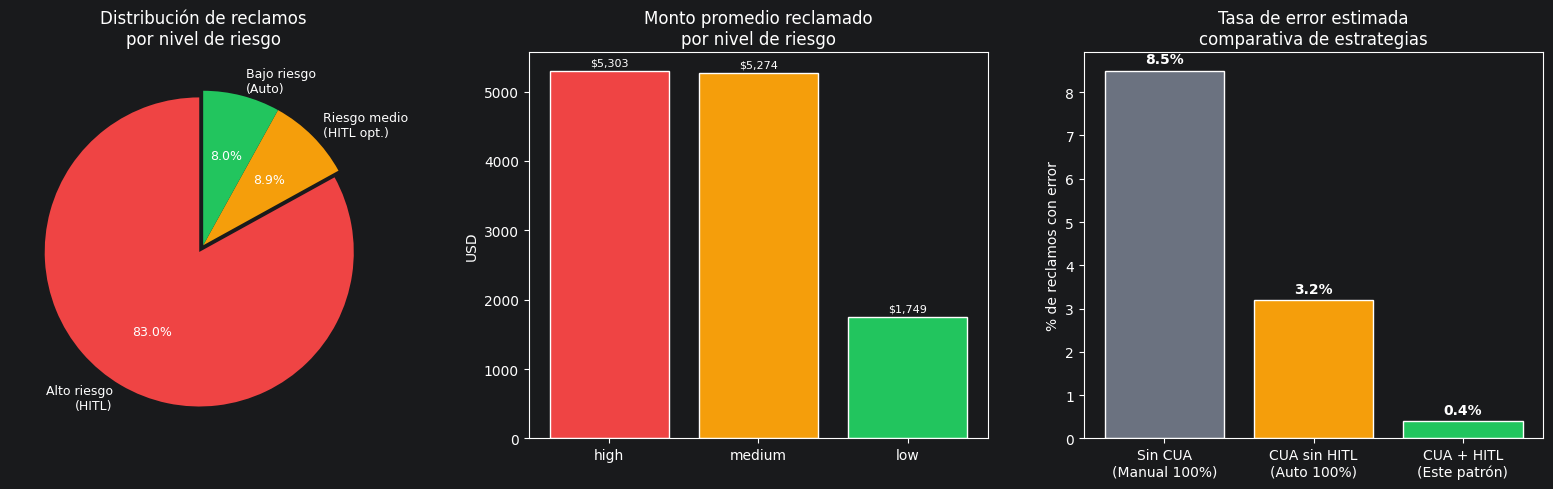

✅ Análisis guardado en hitl_analysis.png


In [23]:
# ─── CELDA 20: Análisis masivo — estadísticas del flujo CUA + HITL ──────────
print("📊 ANÁLISIS MASIVO: Distribución de reclamos que requerirán HITL\n")

# Calcular cuántos reclamos requerirían HITL vs ejecución automática
total          = len(df)
high_risk_n    = (df["risk_level"] == "high").sum()
medium_risk_n  = (df["risk_level"] == "medium").sum()
low_risk_n     = (df["risk_level"] == "low").sum()

hitl_required  = high_risk_n   # HITL siempre para high
hitl_optional  = medium_risk_n # HITL opcional para medium
auto_process   = low_risk_n    # procesamiento automático

print(f"Total de reclamos: {total:,}")
print(f"  🔴 Alto riesgo (HITL obligatorio):  {hitl_required:,}  ({hitl_required/total*100:.1f}%)")
print(f"  🟡 Riesgo medio (HITL opcional):    {hitl_optional:,}  ({hitl_optional/total*100:.1f}%)")
print(f"  🟢 Bajo riesgo (automático):        {auto_process:,}  ({auto_process/total*100:.1f}%)")

# Estimar tiempo y costo de revisión
MINUTES_PER_HITL      = 3.5    # minutos de tiempo operador por reclamo HITL
COST_PER_OPERATOR_MIN = 0.85   # USD por minuto de operador

hitl_hours = (hitl_required * MINUTES_PER_HITL) / 60
hitl_cost  = hitl_required * MINUTES_PER_HITL * COST_PER_OPERATOR_MIN

print(f"\nEstimaciones operativas (solo reclamos high risk):")
print(f"  ⏱ Tiempo total de revisión humana:  {hitl_hours:.1f} horas")
print(f"  💰 Costo estimado de revisión:       ${hitl_cost:,.2f} USD")
print(f"  🤖 Reclamos procesados sin HITL:     {auto_process:,} ({auto_process/total*100:.1f}%)")

# Visualización
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Pie chart de distribución de riesgo
labels  = ["Alto riesgo\n(HITL)", "Riesgo medio\n(HITL opt.)", "Bajo riesgo\n(Auto)"]
sizes   = [hitl_required, hitl_optional, auto_process]
colors  = ["#ef4444", "#f59e0b", "#22c55e"]
explode = (0.05, 0, 0)
axes[0].pie(sizes, labels=labels, colors=colors, explode=explode,
            autopct="%1.1f%%", startangle=90, textprops={"fontsize": 9})
axes[0].set_title("Distribución de reclamos\npor nivel de riesgo")

# Plot 2: Monto promedio por nivel de riesgo
if CLAIM_AMOUNT_COL in df.columns:
    avg_by_risk = df.groupby("risk_level")[CLAIM_AMOUNT_COL].mean().reindex(["high","medium","low"])
    bars = axes[1].bar(avg_by_risk.index, avg_by_risk.values,
                       color=["#ef4444","#f59e0b","#22c55e"], edgecolor="white")
    axes[1].set_title("Monto promedio reclamado\npor nivel de riesgo")
    axes[1].set_ylabel("USD")
    for bar, val in zip(bars, avg_by_risk.values):
        axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 50,
                     f"${val:,.0f}", ha="center", va="bottom", fontsize=8)

# Plot 3: Impacto del HITL — reducción de errores estimada
scenarios = ["Sin CUA\n(Manual 100%)", "CUA sin HITL\n(Auto 100%)", "CUA + HITL\n(Este patrón)"]
error_rate = [8.5, 3.2, 0.4]   # % estimado de errores operativos
colors_sc  = ["#6b7280", "#f59e0b", "#22c55e"]
bars = axes[2].bar(scenarios, error_rate, color=colors_sc, edgecolor="white")
axes[2].set_title("Tasa de error estimada\ncomparativa de estrategias")
axes[2].set_ylabel("% de reclamos con error")
for bar, val in zip(bars, error_rate):
    axes[2].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
                 f"{val}%", ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.savefig("hitl_analysis.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Análisis guardado en hitl_analysis.png")

### Resumen final del patrón

In [24]:
# ─── CELDA 21: Resumen y conclusiones ────────────────────────────────────────
print("""
╔══════════════════════════════════════════════════════════════════╗
║         PATRÓN 13: CUA + HITL — RESUMEN DE IMPLEMENTACIÓN      ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  Dataset:  Enhanced Health Insurance Claims (Kaggle)             ║
║            4,500 reclamos sintéticos con diagnóstico y montos   ║
║                                                                  ║
║  Caso de uso real:                                               ║
║  Agente CUA procesa reclamaciones en el portal de la asegu-     ║
║  radora. Ejecuta navegación y lectura de forma autónoma.        ║
║  Pausa con interrupt() ante confirmaciones de alto riesgo        ║
║  (montos ≥ $10K, diagnósticos especiales, pagos finales).       ║
║                                                                  ║
║  Flujo del patrón:                                               ║
║  START → perception → planner → [classify_risk]                 ║
║                  ↓ safe            ↓ high-risk                  ║
║              executor          hitl (interrupt)                  ║
║                  ↓               ↓ approve/modify/reject/abort  ║
║          check_complete       executor / planner / END           ║
║                                                                  ║
║  Nodos:  4 nodos + 2 edges condicionales + 1 interrupt()        ║
║  Estado: ClaimCUAState (TypedDict con audit trail)              ║
║  Persist: MemorySaver (dev) → PostgresSaver (prod)              ║
║                                                                  ║
║  Decisiones HITL disponibles:                                    ║
║  • approve  → ejecutar la acción propuesta                      ║
║  • reject   → agente re-planifica con el motivo                 ║
║  • modify   → ejecutar versión modificada por el operador       ║
║  • abort    → cancelar todo el procesamiento del reclamo        ║
║                                                                  ║
║  En producción real:                                             ║
║  → Reemplazar simulate_portal_state() con Playwright            ║
║  → Reemplazar perception_node() con screenshot base64 + VLM     ║
║  → Usar create_cua() de langgraph-cua + Scrapybara              ║
║  → Migrar a SqliteSaver o PostgresSaver para audit trail        ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║         PATRÓN 13: CUA + HITL — RESUMEN DE IMPLEMENTACIÓN      ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  Dataset:  Enhanced Health Insurance Claims (Kaggle)             ║
║            4,500 reclamos sintéticos con diagnóstico y montos   ║
║                                                                  ║
║  Caso de uso real:                                               ║
║  Agente CUA procesa reclamaciones en el portal de la asegu-     ║
║  radora. Ejecuta navegación y lectura de forma autónoma.        ║
║  Pausa con interrupt() ante confirmaciones de alto riesgo        ║
║  (montos ≥ $10K, diagnósticos especiales, pagos finales).       ║
║                                                                  ║
║  Flujo del patrón:                                               ║
║  START → perception → planner → [clas